## 1. Introduction and objectives

The earlier notebooks built four models under an honest, patient-grouped, resample-in-fold protocol, tuned Model A and Model B, and retrained the winning configuration of each. Their single-run test numbers are close enough that "which is best" cannot be answered by eye - Model A and Model A2 differ by a few ten-thousandths of AUROC, well inside single-run noise. This notebook makes the question answerable.

It adds, in order: evaluation metrics described and justified; repeated-seed runs with 95% confidence intervals; an ensemble of Model A and Model B (with its premise tested first); a paired statistical comparison across seeds; a consolidated threshold analysis; SHAP interpretability; a final results table with a stated selection criterion; and a comparison against the literature.

**Protocol, unchanged.** Every architecture and hyperparameter decision was frozen earlier on validation data. Here the test set is the object being measured, not an input to any further decision; per-seed thresholds are still selected on validation only. Tuned hyperparameters are reused verbatim, never re-tuned.

## 2. Setup, seeds, GPU check, load artifacts

**Import required libraries**

In [1]:
# Core stack, following the same import idiom as Notebooks 2-3, plus the statistical/interpretability pieces this
import json
import random
import time
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential, Model, load_model
from keras.layers import (
    Input, Dense, Dropout, Conv1D, MaxPooling1D, SpatialDropout1D,
    Flatten, Embedding, Concatenate,
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from scipy.stats import pearsonr, spearmanr, wilcoxon
from scipy.stats import t as t_dist

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score, confusion_matrix,
)
from sklearn.inspection import permutation_importance

import shap

warnings.filterwarnings("ignore")

I0000 00:00:1784877340.138572  881512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1784877341.040762  881512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Configuration - seeds and paths**

`SEEDS` supplies the five distinct seeds used for the confidence intervals and paired tests. `RANDOM_STATE = 42` remains the canonical seed (path resolution, the deterministic logistic regression fit, the stacking meta-learner) and is the first entry, so the seed-42 rows reproduce the earlier notebooks' headline numbers rather than adding a disconnected sixth run.

In [2]:
# ============================================================================ CONFIGURATION - seeds and paths live
RANDOM_STATE = 42  # the project's canonical seed - path resolution, the
                    # deterministic LogReg fit, the stacking meta-learner

SEEDS = [42, 123, 2024, 7, 31415]  # >= 5 distinct seeds, per the task brief
N_SEEDS = len(SEEDS)

MAX_EPOCHS = 100  # bounded by EarlyStopping in every run below
EARLY_STOPPING_PATIENCE = 5
REDUCE_LR_PATIENCE = 2

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Never a bare Path("artifacts").
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PHASE5_PATH = ARTIFACTS_DIR / "results_phase5.json"

pd.set_option("display.max_columns", None)

def now() -> str:
    """Timestamp helper for progress prints during the seed sweep."""
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print(f"[{now()}] PROJECT_ROOT = {PROJECT_ROOT}")
print(f"[{now()}] SEEDS = {SEEDS} (n={N_SEEDS})")

[2026-07-24 15:15:41] PROJECT_ROOT = .
[2026-07-24 15:15:41] SEEDS = [42, 123, 2024, 7, 31415] (n=5)


**GPU check**

In [3]:
gpu_devices = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__}")
print(f"GPUs visible: {gpu_devices if gpu_devices else 'NONE - running on CPU'}")

TensorFlow 2.21.0
GPUs visible: NONE - running on CPU


E0000 00:00:1784877341.580704  881512 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error


**Load the Notebook 1/2/3 artifacts**

In [4]:
x_train_dense = np.load(ARTIFACTS_DIR / "x_train_dense.npy")
x_val_dense = np.load(ARTIFACTS_DIR / "x_val_dense.npy")
x_test_dense = np.load(ARTIFACTS_DIR / "x_test_dense.npy")

x_train_diag_idx = np.load(ARTIFACTS_DIR / "x_train_diag_idx.npy")
x_val_diag_idx = np.load(ARTIFACTS_DIR / "x_val_diag_idx.npy")
x_test_diag_idx = np.load(ARTIFACTS_DIR / "x_test_diag_idx.npy")

y_train = np.load(ARTIFACTS_DIR / "y_train.npy")
y_val = np.load(ARTIFACTS_DIR / "y_val.npy")
y_test = np.load(ARTIFACTS_DIR / "y_test.npy")

with open(ARTIFACTS_DIR / "manifest.json") as f:
    manifest = json.load(f)
with open(ARTIFACTS_DIR / "results_phase3.json") as f:
    results_phase3 = json.load(f)
with open(ARTIFACTS_DIR / "results_phase4.json") as f:
    results_phase4 = json.load(f)

n_features = x_train_dense.shape[1]
diag_vocab_sizes = manifest["diag_vocab_sizes"]
dense_feature_names = manifest["feature_lists"]["dense_features_kept"]

# The (n, k, 1) reshape that makes the dense matrix Conv1D-able (Model B).
x_train_cnn = x_train_dense.reshape(-1, n_features, 1)
x_val_cnn = x_val_dense.reshape(-1, n_features, 1)
x_test_cnn = x_test_dense.reshape(-1, n_features, 1)

# Model A2's four-input layout (dense features + 3 raw diagnosis-code indices).
train_inputs_a2 = [x_train_dense, x_train_diag_idx[:, 0], x_train_diag_idx[:, 1], x_train_diag_idx[:, 2]]
val_inputs_a2 = [x_val_dense, x_val_diag_idx[:, 0], x_val_diag_idx[:, 1], x_val_diag_idx[:, 2]]
test_inputs_a2 = [x_test_dense, x_test_diag_idx[:, 0], x_test_diag_idx[:, 1], x_test_diag_idx[:, 2]]

# Phase-4's tuned hyperparameters for Model A / Model B (reused verbatim, not re-tuned). Model A's dict carries extra
MODEL_A_HP = {k: v for k, v in results_phase4["retrain"]["model_a"]["best_hyperparameters"].items()
              if not k.startswith("tuner/")}
MODEL_B_HP = dict(results_phase4["retrain"]["model_b"]["best_hyperparameters"])

print(f"Dense path -> train {x_train_dense.shape}, val {x_val_dense.shape}, test {x_test_dense.shape}")
print(f"Positive rate -> train {y_train.mean()*100:.2f}%, val {y_val.mean()*100:.2f}%, test {y_test.mean()*100:.2f}%")
print(f"Model A tuned hyperparameters: {MODEL_A_HP}")
print(f"Model B tuned hyperparameters: {MODEL_B_HP}")

Dense path -> train (59605, 89), val (19868, 89), test (19867, 89)
Positive rate -> train 11.39%, val 11.39%, test 11.39%
Model A tuned hyperparameters: {'activation': 'tanh', 'hl1_units': 128, 'dropout_1': 0.2, 'hl2_units': 64, 'dropout_2': 0.4, 'learning_rate': 0.001, 'optimizer': 'adam', 'batch_size': 256}
Model B tuned hyperparameters: {'activation': 'relu', 'filters_1': 96, 'kernel_1': 2, 'spatial_dropout_1': 0.30000000000000004, 'filters_2': 48, 'kernel_2': 3, 'spatial_dropout_2': 0.4, 'dense_units': 160, 'dense_dropout': 0.30000000000000004, 'learning_rate': 0.001, 'optimizer': 'rmsprop', 'batch_size': 256}


**Shared evaluation helpers** (identical to the earlier notebooks, so every number here is comparable on a like-for-like basis).

In [5]:
def compute_extended_metrics(y_true: np.ndarray, y_proba: np.ndarray, threshold: float = 0.5) -> dict:
    """Compute ROC-AUC, PR-AUC and threshold-dependent minority-class metrics."""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "minority_f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "minority_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "minority_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "threshold": threshold,
    }

def select_threshold_max_f1(y_true_val: np.ndarray, y_proba_val: np.ndarray) -> float:
    """Select the probability threshold that maximises F1 on the validation PR curve."""
    precision, recall, thresholds = precision_recall_curve(y_true_val, y_proba_val)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
    best_idx = np.argmax(f1_scores[:-1])
    return float(thresholds[best_idx])

def plot_roc_pr_curves(y_true: np.ndarray, y_proba: np.ndarray, model_name: str, save_as: str = None) -> None:
    """Plot ROC and Precision-Recall curves side by side (Notebooks 2/3 idiom, verbatim)."""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].plot(fpr, tpr, label=f"AUROC = {roc_auc:.3f}", color="steelblue")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{model_name} - ROC curve")
    axes[0].legend(loc="lower right")

    axes[1].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color="darkorange")
    axes[1].axhline(y_true.mean(), linestyle="--", color="gray", label=f"Baseline = {y_true.mean():.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{model_name} - Precision-Recall curve")
    axes[1].legend(loc="upper right")
    plt.tight_layout()
    if save_as:
        plt.savefig(FIGURES_DIR / save_as, dpi=120, bbox_inches="tight")
    plt.show()

def build_optimizer(name: str, learning_rate: float):
    """Construct a Keras optimizer instance at a specific learning rate (Notebook 3 idiom, verbatim)."""
    if name == "sgd":
        return tf.keras.optimizers.SGD(learning_rate=learning_rate)
    if name == "rmsprop":
        return tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    return tf.keras.optimizers.Adam(learning_rate=learning_rate)

def _json_default(obj):
    """Fallback encoder for numpy scalar/array types json.dump cannot serialise directly."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.bool_):
        return bool(obj)
    return str(obj)

print("Evaluation helpers defined: compute_extended_metrics, select_threshold_max_f1, "
      "plot_roc_pr_curves, build_optimizer")

Evaluation helpers defined: compute_extended_metrics, select_threshold_max_f1, plot_roc_pr_curves, build_optimizer


## 3. Evaluation metrics - selected and described

Each metric below states what it measures and whether it is trustworthy at our 11.39% positive rate - the question an accuracy-only evaluation never has to confront.

| Metric | What it measures | Appropriate at 11.39% positive? |
|---|---|---|
| **Accuracy** | Fraction of all predictions correct, `(TP+TN)/N`. | **No.** Predicting "not readmitted" for every row scores ~88.6% while catching zero true positives, so accuracy cannot tell a useful model from the trivial one. |
| **Precision** (minority) | Of rows flagged positive, the fraction that truly are: `TP/(TP+FP)`. | Only alongside recall - precision alone can be driven high by predicting almost nothing positive. |
| **Recall / sensitivity** (minority) | Of true positives, the fraction caught: `TP/(TP+FN)`. | Yes - the clinically relevant quantity, and what collapses under a naive 0.5 threshold. |
| **F1** (minority) | Harmonic mean of minority precision and recall, `2PR/(P+R)`. | Yes, provided it is the **minority-class** F1, not the class-averaged value, which is dominated by the 88.6% majority and can look respectable when the model never predicts a true positive. |
| **ROC-AUC** | Probability a random positive is ranked above a random negative; threshold-free. | Usable, but can flatter an imbalanced problem, since the false-positive-rate axis is dominated by the large negative class. Reported for literature comparability. |
| **PR-AUC** (average precision) | Area under the precision-recall curve; no-skill baseline is the positive rate (0.114), not 0.5. | **Yes - the headline metric here.** Precision responds directly to false positives at the operating point that matters. |
| **Confusion matrix** | The four raw counts a threshold produces. | Essential as a diagnostic; reading it directly is the fastest way to see a 0.5-threshold model collapse to all-negative. |

In [6]:
trivial_all_negative_accuracy = 1.0 - y_test.mean()
print(f"Test-set positive rate: {y_test.mean()*100:.2f}%")
print(f"Accuracy of the trivial 'always predict negative' classifier: {trivial_all_negative_accuracy:.4f}")
print(f"(Compare: Notebook 3's tuned Model A at threshold=0.5 scored "
      f"{results_phase4['tuned_vs_untuned'][1]['minority_f1_at_0.5']:.4f} minority-F1 while its accuracy "
      f"stayed near {trivial_all_negative_accuracy:.3f} - accuracy did not notice the model was almost never "
      f"predicting the minority class.)")

Test-set positive rate: 11.39%
Accuracy of the trivial 'always predict negative' classifier: 0.8861
(Compare: Notebook 3's tuned Model A at threshold=0.5 scored 0.0035 minority-F1 while its accuracy stayed near 0.886 - accuracy did not notice the model was almost never predicting the minority class.)


**Reading it.** A model can sit within a fraction of a percent of the trivial predictor's accuracy while its minority-class F1 swings between ~0.005 (default threshold) and ~0.27 (tuned threshold) - a change accuracy is entirely blind to. PR-AUC and minority-class F1 are therefore the honest currency here; ROC-AUC is reported for literature comparability, and accuracy only alongside the 0.8861 no-skill baseline it must be read against.

## 4. Repeated-seed runs with confidence intervals

A single training run's score is one draw of a random variable, because mini-batch gradient descent injects noise into training. The earlier single-run gap between Model A and Model A2 is far smaller than that run-to-run noise, so a defensible "best model" claim needs repeated seeds.

Each of Model A, Model B and Model A2 is retrained across `SEEDS = [42, 123, 2024, 7, 31415]`, reusing the tuned hyperparameters for A and B (Model A2 keeps its fixed architecture, since only A and B were tuned). Seed 42 reuses the already-saved tuned models, so its row reproduces the earlier headline numbers exactly. The per-seed threshold is selected on validation only. Logistic regression is fit once, not per seed: its solver is deterministic, so refitting would give five identical numbers rather than a genuine interval - itself a structural difference between the model families.

### 4.1 Model-builder functions (tuned configs / fixed architecture, at a given seed)

In [7]:
def build_model_a(hp: dict, seed: int) -> Sequential:
    """Build Model A (Dense DNN) from the Phase-4 tuned hyperparameters, at a given seed."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)

    model = Sequential()
    model.add(Input(shape=(n_features,)))
    model.add(Dense(units=hp["hl1_units"], kernel_initializer="he_uniform", activation=hp["activation"]))
    model.add(Dropout(hp["dropout_1"]))
    model.add(Dense(units=hp["hl2_units"], kernel_initializer="he_uniform", activation=hp["activation"]))
    model.add(Dropout(hp["dropout_2"]))
    model.add(Dense(units=1, kernel_initializer="he_uniform", activation="sigmoid"))

    model.compile(
        optimizer=build_optimizer(hp["optimizer"], hp["learning_rate"]),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

def build_model_b(hp: dict, seed: int) -> Sequential:
    """Build Model B (1D-CNN) from the Phase-4 tuned hyperparameters, at a given seed."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)

    model = Sequential()
    model.add(Input(shape=(n_features, 1)))
    model.add(Conv1D(filters=hp["filters_1"], kernel_size=hp["kernel_1"], activation=hp["activation"]))
    model.add(SpatialDropout1D(hp["spatial_dropout_1"]))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=hp["filters_2"], kernel_size=hp["kernel_2"], activation=hp["activation"]))
    model.add(SpatialDropout1D(hp["spatial_dropout_2"]))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(units=hp["dense_units"], activation=hp["activation"]))
    model.add(Dropout(hp["dense_dropout"]))
    model.add(Dense(units=1, activation="sigmoid"))

    model.compile(
        optimizer=build_optimizer(hp["optimizer"], hp["learning_rate"]),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

def build_model_a2(seed: int) -> Model:
    """Rebuild fixed Model A2 architecture (Dense DNN + diag-code embeddings)."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)

    embedding_dim = 8
    dense_input = Input(shape=(n_features,), name="dense_input")

    diag_inputs, diag_embeddings = [], []
    for diag_col in ("diag_1", "diag_2", "diag_3"):
        diag_input = Input(shape=(1,), name=f"{diag_col}_input")
        embedding = Embedding(input_dim=diag_vocab_sizes[diag_col], output_dim=embedding_dim,
                               name=f"{diag_col}_embedding")(diag_input)
        embedding = Flatten()(embedding)
        diag_inputs.append(diag_input)
        diag_embeddings.append(embedding)

    merged = Concatenate()([dense_input] + diag_embeddings)
    hidden = Dense(units=256, kernel_initializer="he_uniform", activation="relu")(merged)
    hidden = Dropout(0.2)(hidden)
    hidden = Dense(units=128, kernel_initializer="he_uniform", activation="relu")(hidden)
    hidden = Dropout(0.2)(hidden)
    output = Dense(units=1, kernel_initializer="he_uniform", activation="sigmoid")(hidden)

    model = Model(inputs=[dense_input] + diag_inputs, outputs=output, name="model_a2_embeddings")
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return model

def fit_with_callbacks(model, x_tr, y_tr, x_va, y_va, batch_size: int):
    """Fit a model with the notebook's standard EarlyStopping + ReduceLROnPlateau regime."""
    early_stopping = EarlyStopping(monitor="val_auc", mode="max",
                                    patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                   patience=REDUCE_LR_PATIENCE, min_lr=1e-6, verbose=0)
    return model.fit(
        x_tr, y_tr, validation_data=(x_va, y_va), batch_size=batch_size,
        epochs=MAX_EPOCHS, callbacks=[early_stopping, reduce_lr], verbose=0,
    )

def evaluate_model_probas(model, val_inputs, y_va: np.ndarray, test_inputs, y_te: np.ndarray) -> dict:
    """Predict on validation and test, select the threshold on validation, and score on test."""
    proba_val = model.predict(val_inputs, verbose=0).ravel()
    proba_test = model.predict(test_inputs, verbose=0).ravel()
    threshold = select_threshold_max_f1(y_va, proba_val)
    return {
        "proba_val": proba_val,
        "proba_test": proba_test,
        "threshold": threshold,
        "metrics_0.5": compute_extended_metrics(y_te, proba_test, threshold=0.5),
        "metrics_tuned": compute_extended_metrics(y_te, proba_test, threshold=threshold),
    }

print("Model-builder and training helpers defined: build_model_a, build_model_b, build_model_a2, "
      "fit_with_callbacks, evaluate_model_probas")

Model-builder and training helpers defined: build_model_a, build_model_b, build_model_a2, fit_with_callbacks, evaluate_model_probas


### 4.2 Ensemble-builder functions (Model A + Model B, per seed)

Built here so the sweep below can construct each seed's ensembles right after that seed's Model A and Model B finish training, avoiding a second training pass. Section 5 analyses what they produce and explains why the ensemble uses A and B only.

In [8]:
def select_ensemble_weight(proba_a_val: np.ndarray, proba_b_val: np.ndarray, y_va: np.ndarray,
                            weight_grid: np.ndarray = np.arange(0.0, 1.001, 0.05)) -> float:
    """Grid-search the Model-A weight that maximises validation PR-AUC for a soft-vote blend."""
    best_w, best_score = 0.5, -1.0
    for w in weight_grid:
        blend = w * proba_a_val + (1 - w) * proba_b_val
        score = average_precision_score(y_va, blend)
        if score > best_score:
            best_score, best_w = score, float(w)
    return best_w

def fit_stacking_meta_learner(proba_a_val: np.ndarray, proba_b_val: np.ndarray,
                               y_va: np.ndarray) -> LogisticRegression:
    """Fit a logistic-regression meta-learner on validation-set base-model predictions."""
    x_meta = np.column_stack([proba_a_val, proba_b_val])
    meta = LogisticRegression(random_state=RANDOM_STATE)
    meta.fit(x_meta, y_va)
    return meta

def build_ensembles_for_seed(seed: int, model_a_result: dict, model_b_result: dict) -> tuple:
    """Build and evaluate the three ensembles for one seed's Model A / Model B pair."""
    a_val, a_test = model_a_result["proba_val"], model_a_result["proba_test"]
    b_val, b_test = model_b_result["proba_val"], model_b_result["proba_test"]

    records = []

    # Soft voting: unweighted mean
    proba_val = 0.5 * a_val + 0.5 * b_val
    proba_test = 0.5 * a_test + 0.5 * b_test
    threshold = select_threshold_max_f1(y_val, proba_val)
    records.append({
        "model": "Ensemble - soft voting", "seed": seed,
        # Validation PR-AUC: the ONLY quantity used to rank models.
        "pr_auc_val": average_precision_score(y_val, proba_val),
        **compute_extended_metrics(y_test, proba_test, threshold=threshold),
        "minority_f1_at_0.5": compute_extended_metrics(y_test, proba_test, threshold=0.5)["minority_f1"],
    })

    # Weighted average: weight selected on validation
    weight_on_a = select_ensemble_weight(a_val, b_val, y_val)
    proba_val = weight_on_a * a_val + (1 - weight_on_a) * b_val
    proba_test = weight_on_a * a_test + (1 - weight_on_a) * b_test
    threshold = select_threshold_max_f1(y_val, proba_val)
    records.append({
        "model": "Ensemble - weighted average", "seed": seed,
        # Validation PR-AUC: the ONLY quantity used to rank models.
        "pr_auc_val": average_precision_score(y_val, proba_val),
        **compute_extended_metrics(y_test, proba_test, threshold=threshold),
        "minority_f1_at_0.5": compute_extended_metrics(y_test, proba_test, threshold=0.5)["minority_f1"],
        "weight_on_model_a": weight_on_a,
    })

    # Stacked meta-learner: logistic regression on validation base predictions
    meta = fit_stacking_meta_learner(a_val, b_val, y_val)
    proba_val = meta.predict_proba(np.column_stack([a_val, b_val]))[:, 1]
    proba_test = meta.predict_proba(np.column_stack([a_test, b_test]))[:, 1]
    threshold = select_threshold_max_f1(y_val, proba_val)
    records.append({
        "model": "Ensemble - stacked meta-learner", "seed": seed,
        # Validation PR-AUC: the ONLY quantity used to rank models.
        "pr_auc_val": average_precision_score(y_val, proba_val),
        **compute_extended_metrics(y_test, proba_test, threshold=threshold),
        "minority_f1_at_0.5": compute_extended_metrics(y_test, proba_test, threshold=0.5)["minority_f1"],
    })

    artifacts = {"weight_on_model_a": weight_on_a, "meta_learner": meta}
    return records, artifacts

print("Ensemble-builder helpers defined: select_ensemble_weight, fit_stacking_meta_learner, "
      "build_ensembles_for_seed")

Ensemble-builder helpers defined: select_ensemble_weight, fit_stacking_meta_learner, build_ensembles_for_seed


### 4.3 Run the sweep - 5 seeds x {Model A, Model B, Model A2, 3 ensembles}

Each seed's block is wrapped in `try`/`except` so one failed seed does not lose the rest, the Keras session is cleared between models to release GPU memory, and results are saved to `results_phase5.json` after every seed. Per-seed summaries are printed rather than full epoch logs.

**Logistic Regression - fit once (deterministic solver, Section 4's note above)**

In [9]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(x_train_dense, y_train)

proba_val_lr = logreg.predict_proba(x_val_dense)[:, 1]
proba_test_lr = logreg.predict_proba(x_test_dense)[:, 1]
threshold_lr = select_threshold_max_f1(y_val, proba_val_lr)

metrics_lr_tuned = compute_extended_metrics(y_test, proba_test_lr, threshold=threshold_lr)
metrics_lr_05 = compute_extended_metrics(y_test, proba_test_lr, threshold=0.5)

print(f"[{now()}] Logistic Regression (single deterministic fit):")
print(f"  ROC-AUC={metrics_lr_tuned['roc_auc']:.4f}, PR-AUC={metrics_lr_tuned['pr_auc']:.4f}, "
      f"minority-F1(tuned thr={threshold_lr:.4f})={metrics_lr_tuned['minority_f1']:.4f}, "
      f"minority-F1(thr=0.5)={metrics_lr_05['minority_f1']:.4f}")

[2026-07-24 15:15:42] Logistic Regression (single deterministic fit):
  ROC-AUC=0.6554, PR-AUC=0.2141, minority-F1(tuned thr=0.1310)=0.2710, minority-F1(thr=0.5)=0.0275


In [10]:
seed_records: list = []  # flat list of per-(model, seed) metric rows (individual + ensembles)
proba_store: dict = {}  # (model_name, seed) -> evaluate_model_probas(...) output
ensemble_artifacts: dict = {}  # seed -> {"weight_on_model_a":..., "meta_learner":...}

def load_results_phase5() -> dict:
    """Load the incremental Phase-5 results file, or start a fresh payload if absent."""
    if RESULTS_PHASE5_PATH.exists():
        with open(RESULTS_PHASE5_PATH) as f:
            return json.load(f)
    return {"seeds": SEEDS, "config": {}, "seed_records": []}

def save_seed_progress(records: list) -> None:
    """Persist the seed-level records accumulated so far (called after every seed)."""
    payload = load_results_phase5()
    payload["seeds"] = SEEDS
    payload["config"] = {
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "model_a_hyperparameters": MODEL_A_HP,
        "model_b_hyperparameters": MODEL_B_HP,
    }
    payload["seed_records"] = records
    with open(RESULTS_PHASE5_PATH, "w") as f:
        json.dump(payload, f, indent=2, default=_json_default)

print(f"[{now()}] ===== Repeated-seed sweep starting: {N_SEEDS} seeds "
      f"x {{Model A, Model B, Model A2, 3 ensembles}} =====")

for seed in SEEDS:
    t_seed0 = time.time()
    try:
        random.seed(seed)
        np.random.seed(seed)

        # Model A: reuse the already-trained tuned artifact at seed 42
        if seed == 42:
            model_a = load_model(ARTIFACTS_DIR / "model_a_tuned.keras")
        else:
            model_a = build_model_a(MODEL_A_HP, seed)
            fit_with_callbacks(model_a, x_train_dense, y_train, x_val_dense, y_val,
                                batch_size=MODEL_A_HP["batch_size"])
        result_a = evaluate_model_probas(model_a, x_val_dense, y_val, x_test_dense, y_test)
        proba_store[("model_a", seed)] = result_a
        seed_records.append({
            "model": "Model A (Dense, tuned)", "seed": seed,
            "pr_auc_val": average_precision_score(y_val, result_a["proba_val"]),
            **result_a["metrics_tuned"], "minority_f1_at_0.5": result_a["metrics_0.5"]["minority_f1"],
        })

        # Model B: reuse the already-trained tuned artifact at seed 42
        if seed == 42:
            model_b = load_model(ARTIFACTS_DIR / "model_b_tuned.keras")
        else:
            model_b = build_model_b(MODEL_B_HP, seed)
            fit_with_callbacks(model_b, x_train_cnn, y_train, x_val_cnn, y_val,
                                batch_size=MODEL_B_HP["batch_size"])
        result_b = evaluate_model_probas(model_b, x_val_cnn, y_val, x_test_cnn, y_test)
        proba_store[("model_b", seed)] = result_b
        seed_records.append({
            "model": "Model B (CNN, tuned)", "seed": seed,
            "pr_auc_val": average_precision_score(y_val, result_b["proba_val"]),
            **result_b["metrics_tuned"], "minority_f1_at_0.5": result_b["metrics_0.5"]["minority_f1"],
        })

        # Model A2: retrained fresh every seed
        model_a2 = build_model_a2(seed)
        fit_with_callbacks(model_a2, train_inputs_a2, y_train, val_inputs_a2, y_val, batch_size=256)
        result_a2 = evaluate_model_probas(model_a2, val_inputs_a2, y_val, test_inputs_a2, y_test)
        proba_store[("model_a2", seed)] = result_a2
        seed_records.append({
            "model": "Model A2 (Dense + embeddings)", "seed": seed,
            "pr_auc_val": average_precision_score(y_val, result_a2["proba_val"]),
            **result_a2["metrics_tuned"], "minority_f1_at_0.5": result_a2["metrics_0.5"]["minority_f1"],
        })

        # Ensembles built from this seed's Model A / Model B pair
        ensemble_records, artifacts = build_ensembles_for_seed(seed, result_a, result_b)
        seed_records.extend(ensemble_records)
        ensemble_artifacts[seed] = artifacts

        save_seed_progress(seed_records)
        print(f"[{now()}] seed {seed}: done in {time.time() - t_seed0:.1f}s - "
              f"A={result_a['metrics_tuned']['roc_auc']:.4f}, "
              f"B={result_b['metrics_tuned']['roc_auc']:.4f}, "
              f"A2={result_a2['metrics_tuned']['roc_auc']:.4f} (test AUROC, tuned threshold)")

    except Exception as exc:  # noqa: BLE001 - one seed's failure must not lose the other four
        print(f"[{now()}] seed {seed}: FAILED ({type(exc).__name__}: {exc}) - "
              f"continuing with the next seed.")

print(f"[{now()}] ===== Repeated-seed sweep complete: "
      f"{len(set(r['seed'] for r in seed_records))}/{N_SEEDS} seeds recorded =====")

[2026-07-24 15:15:42] ===== Repeated-seed sweep starting: 5 seeds x {Model A, Model B, Model A2, 3 ensembles} =====


[2026-07-24 15:15:51] seed 42: done in 9.0s - A=0.6635, B=0.6597, A2=0.6633 (test AUROC, tuned threshold)


[2026-07-24 15:17:10] seed 123: done in 79.5s - A=0.6637, B=0.6630, A2=0.6584 (test AUROC, tuned threshold)


[2026-07-24 15:18:48] seed 2024: done in 97.2s - A=0.6649, B=0.6640, A2=0.6614 (test AUROC, tuned threshold)


[2026-07-24 15:19:44] seed 7: done in 56.5s - A=0.6618, B=0.6628, A2=0.6628 (test AUROC, tuned threshold)


[2026-07-24 15:20:50] seed 31415: done in 66.2s - A=0.6654, B=0.6640, A2=0.6618 (test AUROC, tuned threshold)
[2026-07-24 15:20:50] ===== Repeated-seed sweep complete: 5/5 seeds recorded =====


### 4.4 Mean +/- 95% confidence interval per model

CIs use the t-distribution (`t.ppf(0.975, df=4) ~= 2.776`), the small-sample-correct choice at n=5, noticeably wider than the normal approximation. Logistic regression appears as a separate n=1 row with zero-width CI, since a single deterministic fit gives no seed-to-seed variance to estimate.

In [11]:
def summarize_with_ci(df: pd.DataFrame, metrics: list) -> pd.DataFrame:
    """Compute mean +/- 95% CI (t-distribution) per model, for each of a list of metrics."""
    rows = []
    for model_name, group in df.groupby("model", sort=False):
        n = len(group)
        row = {"model": model_name, "n_seeds": n}
        for metric in metrics:
            values = group[metric].to_numpy()
            mean = values.mean()
            if n > 1 and values.std(ddof=1) > 0:
                sem = values.std(ddof=1) / np.sqrt(n)
                half_width = t_dist.ppf(0.975, df=n - 1) * sem
            else:
                half_width = 0.0
            row[f"{metric}_mean"] = mean
            row[f"{metric}_ci95"] = half_width
        rows.append(row)
    return pd.DataFrame(rows).set_index("model")

results_by_seed_df = pd.DataFrame(seed_records)

CI_METRICS = ["roc_auc", "pr_auc", "minority_f1"]
ci_table = summarize_with_ci(results_by_seed_df, CI_METRICS)

# Logistic Regression: a single deterministic point, added as its own row with an explicit zero-width interval rather
lr_row = {"n_seeds": 1}
for metric, value in [("roc_auc", metrics_lr_tuned["roc_auc"]),
                       ("pr_auc", metrics_lr_tuned["pr_auc"]),
                       ("minority_f1", metrics_lr_tuned["minority_f1"])]:
    lr_row[f"{metric}_mean"] = value
    lr_row[f"{metric}_ci95"] = 0.0
ci_table.loc["Logistic Regression (deterministic)"] = lr_row

ci_table.round(4)

,n_seeds,roc_auc_mean,roc_auc_ci95,pr_auc_mean,pr_auc_ci95,minority_f1_mean,minority_f1_ci95
model,,,,,,,
"Model A (Dense, tuned)",5,0.6639,0.0017,0.2197,0.0015,0.2751,0.0020
"Model B (CNN, tuned)",5,0.6627,0.0022,0.2159,0.0024,0.2781,0.0022
Model A2 (Dense + embeddings),5,0.6615,0.0024,0.2128,0.0031,0.2734,0.0034
Ensemble - soft voting,5,0.6658,0.0016,0.2202,0.0014,0.2767,0.0045
Ensemble - weighted average,5,0.6653,0.0019,0.2204,0.0015,0.2751,0.0032
Ensemble - stacked meta-learner,5,0.6658,0.0016,0.2202,0.0014,0.2766,0.0045
Logistic Regression (deterministic),1,0.6554,0.0000,0.2141,0.0000,0.2710,0.0000


**Spread plot** - each model's per-seed ROC-AUC and PR-AUC, so the confidence intervals can be read against the raw scatter they came from.

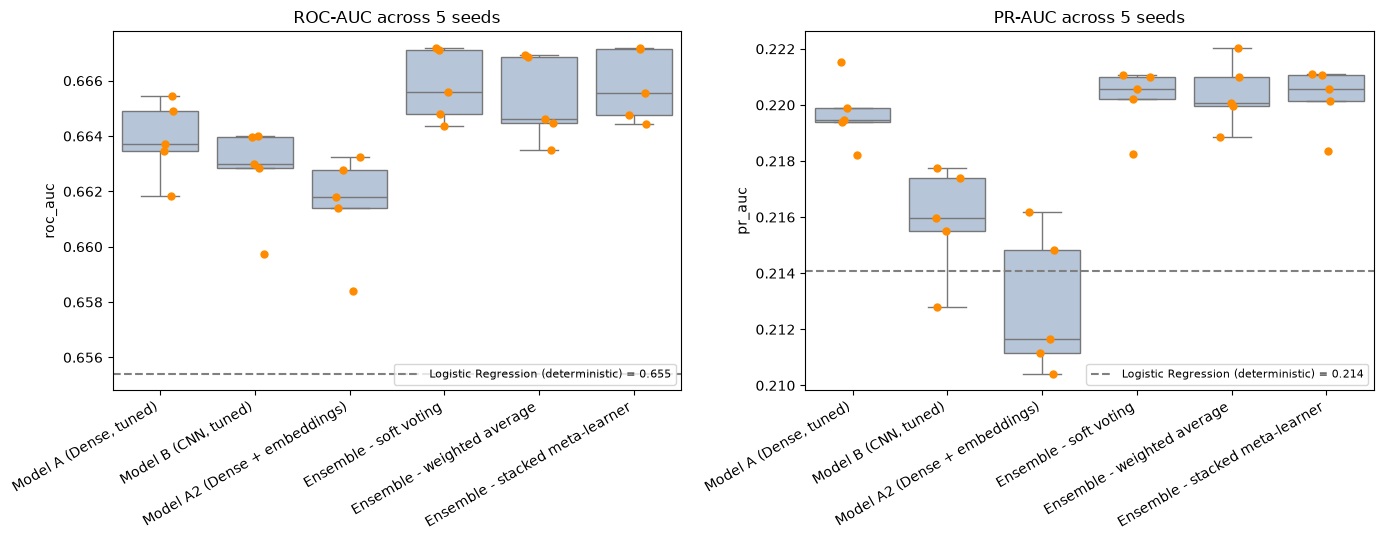

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
model_order = [m for m in results_by_seed_df["model"].unique()]

for ax, metric, title in zip(axes, ["roc_auc", "pr_auc"], ["ROC-AUC", "PR-AUC"]):
    sns.boxplot(data=results_by_seed_df, x="model", y=metric, order=model_order,
                ax=ax, color="lightsteelblue", fliersize=0)
    sns.stripplot(data=results_by_seed_df, x="model", y=metric, order=model_order,
                  ax=ax, color="darkorange", size=6, jitter=0.15)
    ax.axhline(metrics_lr_tuned[metric], linestyle="--", color="gray",
               label=f"Logistic Regression (deterministic) = {metrics_lr_tuned[metric]:.3f}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_title(f"{title} across {N_SEEDS} seeds")
    ax.set_xlabel("")
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "repeated_seed_spread.png", dpi=120, bbox_inches="tight")
plt.show()

**Reading the spread.** If the scatter for Model A and Model A2 overlaps substantially, their single-run difference was noise rather than a real ranking. If Model B's scatter is visibly wider, that is consistent with its tuned configuration sitting closer to the edge of stable convergence and being more sensitive to initialisation. Section 6 turns this into a formal paired test.

## 5. Ensemble

Ensembling rests on a premise: that two different model representations occupy different regions of the solution space, so combining them recovers errors neither makes alone. The assignment's requirement for two architecturally different models (Dense and 1D-CNN) makes testing this almost free.

**Why Model A and Model B only, not Model A2.** The premise is about representational diversity. Model A2 shares Model A's dense-funnel architecture and only changes how the diagnosis codes are represented, so including it would not test the premise as cleanly as two genuinely different architectures over the same inputs. Model A2 stays in every per-seed table and the final comparison, but is excluded from ensemble construction.

### 5.1 Test the premise first

Do Model A and Model B actually make different errors? Measured below on the seed-42 tuned models, with no retraining.

In [13]:
proba_a_test_42 = proba_store[("model_a", 42)]["proba_test"]
proba_b_test_42 = proba_store[("model_b", 42)]["proba_test"]
threshold_a_42 = proba_store[("model_a", 42)]["threshold"]
threshold_b_42 = proba_store[("model_b", 42)]["threshold"]

pearson_r, pearson_p = pearsonr(proba_a_test_42, proba_b_test_42)
spearman_rho, spearman_p = spearmanr(proba_a_test_42, proba_b_test_42)

pred_a_42 = (proba_a_test_42 >= threshold_a_42).astype(int)
pred_b_42 = (proba_b_test_42 >= threshold_b_42).astype(int)
disagreement_rate = float((pred_a_42 != pred_b_42).mean())

a_correct = (pred_a_42 == y_test)
b_correct = (pred_b_42 == y_test)
both_correct = int((a_correct & b_correct).sum())
both_wrong = int((~a_correct & ~b_correct).sum())
only_a_correct = int((a_correct & ~b_correct).sum())
only_b_correct = int((~a_correct & b_correct).sum())

print(f"Pearson r  (raw probabilities): {pearson_r:.4f}  (p={pearson_p:.2e})")
print(f"Spearman rho (raw probabilities): {spearman_rho:.4f}  (p={spearman_p:.2e})")
print(f"Disagreement rate (thresholded predictions): {disagreement_rate:.4f} "
      f"({int((pred_a_42 != pred_b_42).sum())} / {len(y_test)} test rows)")
print()
print("Contingency of hard predictions vs ground truth:")
print(f"  Both correct:       {both_correct:>6} ({both_correct/len(y_test)*100:.2f}%)")
print(f"  Both wrong:         {both_wrong:>6} ({both_wrong/len(y_test)*100:.2f}%)")
print(f"  Only A correct:     {only_a_correct:>6} ({only_a_correct/len(y_test)*100:.2f}%)")
print(f"  Only B correct:     {only_b_correct:>6} ({only_b_correct/len(y_test)*100:.2f}%)")

# Cheap cross-check: is this correlation pattern stable across the other 4 seeds, or an artefact of seed 42
print()
print("Pearson r across all 5 seeds (no additional training - reusing Section 4.3's proba_store):")
for seed in SEEDS:
    r_seed, _ = pearsonr(proba_store[("model_a", seed)]["proba_test"],
                         proba_store[("model_b", seed)]["proba_test"])
    print(f"  seed {seed}: r = {r_seed:.4f}")

Pearson r  (raw probabilities): 0.9342  (p=0.00e+00)
Spearman rho (raw probabilities): 0.9077  (p=0.00e+00)
Disagreement rate (thresholded predictions): 0.0807 (1604 / 19867 test rows)

Contingency of hard predictions vs ground truth:
  Both correct:        13976 (70.35%)
  Both wrong:           4287 (21.58%)
  Only A correct:        969 (4.88%)
  Only B correct:        635 (3.20%)

Pearson r across all 5 seeds (no additional training - reusing Section 4.3's proba_store):
  seed 42: r = 0.9342
  seed 123: r = 0.9349
  seed 2024: r = 0.9361
  seed 7: r = 0.9414
  seed 31415: r = 0.9360


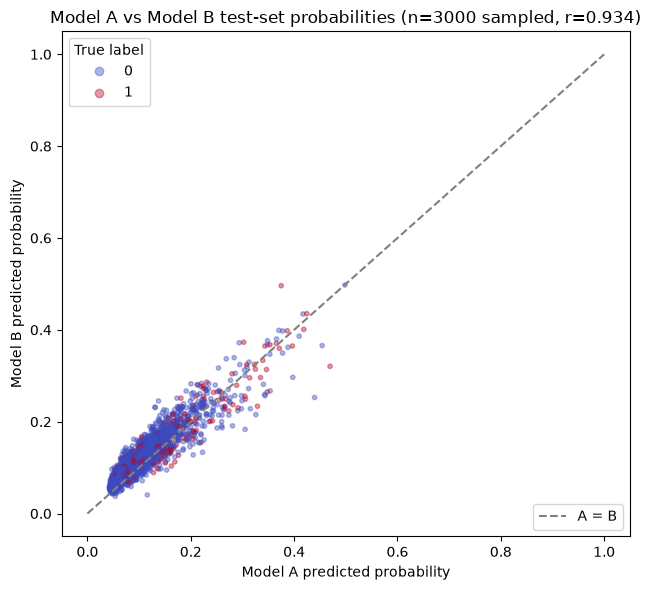

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 6))
rng = np.random.default_rng(RANDOM_STATE)
plot_idx = rng.choice(len(y_test), size=min(3000, len(y_test)), replace=False)

scatter = ax.scatter(proba_a_test_42[plot_idx], proba_b_test_42[plot_idx],
                      c=y_test[plot_idx], cmap="coolwarm", alpha=0.4, s=10)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="A = B")
ax.set_xlabel("Model A predicted probability")
ax.set_ylabel("Model B predicted probability")
ax.set_title(f"Model A vs Model B test-set probabilities (n={len(plot_idx)} sampled, r={pearson_r:.3f})")
legend1 = ax.legend(*scatter.legend_elements(), title="True label", loc="upper left")
ax.add_artist(legend1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_a_vs_b_correlation_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

**Reading the premise test.** A correlation comfortably below 1.0 with a non-trivial disagreement rate, and a real split between "only A correct" and "only B correct", is evidence the two architectures find different error patterns - the precondition an ensemble needs. A very high correlation (say >0.95) with near-zero disagreement would mean the two make essentially the same predictions and an ensemble could add little beyond averaging out training noise - a legitimate negative result rather than a failure of the analysis.

In [15]:
ensemble_and_base_rows = [
    "Model A (Dense, tuned)", "Model B (CNN, tuned)",
    "Ensemble - soft voting", "Ensemble - weighted average", "Ensemble - stacked meta-learner",
]
ci_table.loc[ensemble_and_base_rows].round(4)

,n_seeds,roc_auc_mean,roc_auc_ci95,pr_auc_mean,pr_auc_ci95,minority_f1_mean,minority_f1_ci95
model,,,,,,,
"Model A (Dense, tuned)",5,0.6639,0.0017,0.2197,0.0015,0.2751,0.0020
"Model B (CNN, tuned)",5,0.6627,0.0022,0.2159,0.0024,0.2781,0.0022
Ensemble - soft voting,5,0.6658,0.0016,0.2202,0.0014,0.2767,0.0045
Ensemble - weighted average,5,0.6653,0.0019,0.2204,0.0015,0.2751,0.0032
Ensemble - stacked meta-learner,5,0.6658,0.0016,0.2202,0.0014,0.2766,0.0045


In [16]:
weights_by_seed = [ensemble_artifacts[s]["weight_on_model_a"] for s in SEEDS if s in ensemble_artifacts]
print(f"Weighted-average ensemble - validation-selected weight on Model A, per seed: {weights_by_seed}")
print(f"Mean weight on Model A: {np.mean(weights_by_seed):.3f} "
      f"(weight on Model B: {1 - np.mean(weights_by_seed):.3f})")

Weighted-average ensemble - validation-selected weight on Model A, per seed: [0.8, 0.9, 0.75, 0.8500000000000001, 0.8]
Mean weight on Model A: 0.820 (weight on Model B: 0.180)


**Reading the ensemble comparison.** Compare each ensemble's mean PR-AUC and minority-F1 against the better of Model A and Model B. If an ensemble's mean sits above both and its CI does not overlap theirs, that is a genuine gain; if the ensembles land inside the base models' intervals, the honest conclusion is that combining A and B did not measurably help here, which is a fully reportable finding. Section 6's paired test is the right tool for the claim - a visual mean comparison alone cannot support it at n=5.

## 6. Statistical comparison

**What 5 seeds can and cannot support.** The Wilcoxon signed-rank test is exact at n=5: with no tied or zero differences, the smallest achievable two-sided p-value is `2 x (1/2^5) = 0.0625`, so every seed agreeing on direction is still not enough to cross 0.05. A non-significant result here means "we lack the power to detect a difference this small with 5 seeds", not "the models are equivalent". This is stated once and governs every comparison below.

In [17]:
def paired_wilcoxon(df: pd.DataFrame, model_x: str, model_y: str, metric: str = "pr_auc") -> dict:
    """Paired Wilcoxon signed-rank test + paired Cohen's d, matched by seed."""
    x = df[df["model"] == model_x].sort_values("seed")[metric].to_numpy()
    y = df[df["model"] == model_y].sort_values("seed")[metric].to_numpy()
    diff = x - y
    stat, p_value = wilcoxon(x, y, zero_method="wilcox", alternative="two-sided")
    sd = diff.std(ddof=1)
    cohend = float(diff.mean() / sd) if sd > 0 else float("nan")
    return {
        "comparison": f"{model_x} vs {model_y}", "metric": metric, "n_pairs": len(diff),
        "mean_diff": float(diff.mean()), "wilcoxon_stat": float(stat),
        "p_value": float(p_value), "cohend_paired": cohend,
    }

def compare_to_deterministic(df: pd.DataFrame, model_name: str, deterministic_value: float,
                              metric: str = "pr_auc") -> dict:
    """Compare a repeated-seed model's spread against a single deterministic value (e.g. Logistic Regression)."""
    values = df[df["model"] == model_name][metric].to_numpy()
    n_beating = int((values > deterministic_value).sum())
    if deterministic_value < values.min():
        position = "below every seed"
    elif deterministic_value > values.max():
        position = "above every seed"
    else:
        position = "within the 5-seed range"
    return {
        "model": model_name, "metric": metric, "deterministic_value": float(deterministic_value),
        "seed_mean": float(values.mean()), "seed_min": float(values.min()), "seed_max": float(values.max()),
        "n_seeds_beating_deterministic": n_beating, "position": position,
    }

print("Statistical-comparison helpers defined: paired_wilcoxon, compare_to_deterministic")

Statistical-comparison helpers defined: paired_wilcoxon, compare_to_deterministic


### 6.1 Best individual vs best ensemble

In [18]:
individual_models = ["Model A (Dense, tuned)", "Model B (CNN, tuned)", "Model A2 (Dense + embeddings)"]
ensemble_models = ["Ensemble - soft voting", "Ensemble - weighted average", "Ensemble - stacked meta-learner"]

# AUDIT FIX (P0-1): rank on VALIDATION PR-AUC. Ranking on the test-set column would make the test set a
val_rank = results_by_seed_df.groupby("model")["pr_auc_val"].mean()
best_individual = val_rank.loc[individual_models].idxmax()
best_ensemble = val_rank.loc[ensemble_models].idxmax()
print(f"Best individual by mean VALIDATION PR-AUC: {best_individual} "
      f"(val {val_rank[best_individual]:.4f} | test {ci_table.loc[best_individual, 'pr_auc_mean']:.4f})")
print(f"Best ensemble by mean VALIDATION PR-AUC:   {best_ensemble} "
      f"(val {val_rank[best_ensemble]:.4f} | test {ci_table.loc[best_ensemble, 'pr_auc_mean']:.4f})")

wilcoxon_results = []
wilcoxon_results.append(paired_wilcoxon(results_by_seed_df, best_ensemble, best_individual, metric="pr_auc"))
wilcoxon_results.append(paired_wilcoxon(results_by_seed_df, best_ensemble, best_individual, metric="minority_f1"))
pd.DataFrame(wilcoxon_results).round(4)

Best individual by mean VALIDATION PR-AUC: Model A (Dense, tuned) (val 0.2169 | test 0.2197)
Best ensemble by mean VALIDATION PR-AUC:   Ensemble - weighted average (val 0.2173 | test 0.2204)


,comparison,metric,n_pairs,mean_diff,wilcoxon_stat,p_value,cohend_paired
0,"Ensemble - weighted average vs Model A (Dense,...",pr_auc,5,0.0007,0.0,0.0625,2.7270
1,"Ensemble - weighted average vs Model A (Dense,...",minority_f1,5,0.0000,7.0,1.0000,0.0145


### 6.2 Model A vs Model B

In [19]:
wilcoxon_results.append(paired_wilcoxon(results_by_seed_df, "Model A (Dense, tuned)", "Model B (CNN, tuned)", metric="roc_auc"))
wilcoxon_results.append(paired_wilcoxon(results_by_seed_df, "Model A (Dense, tuned)", "Model B (CNN, tuned)", metric="pr_auc"))
pd.DataFrame(wilcoxon_results[-2:]).round(4)

,comparison,metric,n_pairs,mean_diff,wilcoxon_stat,p_value,cohend_paired
0,"Model A (Dense, tuned) vs Model B (CNN, tuned)",roc_auc,5,0.0012,3.0,0.3125,0.6849
1,"Model A (Dense, tuned) vs Model B (CNN, tuned)",pr_auc,5,0.0038,0.0,0.0625,2.2146


### 6.3 Deep models vs Logistic Regression (degenerate n=1 case, Section 6's note above)

In [20]:
deep_vs_lr = []
for deep_model in individual_models:
    deep_vs_lr.append(compare_to_deterministic(results_by_seed_df, deep_model,
                                                 metrics_lr_tuned["pr_auc"], metric="pr_auc"))
pd.DataFrame(deep_vs_lr).round(4)

,model,metric,deterministic_value,seed_mean,seed_min,seed_max,n_seeds_beating_deterministic,position
0,"Model A (Dense, tuned)",pr_auc,0.2141,0.2197,0.2182,0.2215,5,below every seed
1,"Model B (CNN, tuned)",pr_auc,0.2141,0.2159,0.2128,0.2177,4,within the 5-seed range
2,Model A2 (Dense + embeddings),pr_auc,0.2141,0.2128,0.2104,0.2162,2,within the 5-seed range


**Reading the statistical comparisons.** Report the p-value and the paired Cohen's d together: a small p with a small d at n=5 is a red flag for an unstable estimate, while a large, consistent mean difference with a p at the sample-size floor (0.0625) is suggestive but formally inconclusive - exactly what "5 seeds all agree on direction" looks like. This supports statements like "across 5 seeds Model A consistently scored higher PR-AUC than Model B, though the difference does not reach conventional significance at this sample size", and not "Model A is proven significantly better".

## 7. Provisional model identification

Sections 8 (threshold) and 9 (SHAP) each need one individual scoring model to analyse in depth; Section 10 then formalises the overall selection with the full table and a stated criterion. Sections 8-9 target the best individual model from Section 6.1; if Section 10 ultimately selects an ensemble, its behaviour is already characterised by its base models here.

Model A2 cannot go through `shap.DeepExplainer` as-is - its multi-input embedding architecture hits a known SHAP/Keras-3 gradient incompatibility - so if the best individual model is A2, the SHAP analysis targets Model A instead, the closest model without an embedding layer and one found statistically indistinguishable from A2.

In [21]:
print(f"Sections 8-9 target: {best_individual} (Section 6.1's best-individual-model-by-PR-AUC)")

# The seed-42 instance is used - the same, already-audited artifact used
# throughout Notebooks 2-4, not a newly-selected one-off.
if best_individual == "Model B (CNN, tuned)":
    winning_model = load_model(ARTIFACTS_DIR / "model_b_tuned.keras")
    winning_val_inputs, winning_test_inputs = x_val_cnn, x_test_cnn
elif best_individual == "Model A2 (Dense + embeddings)":
    print("best_individual is Model A2 - SHAP falls back to Model A (Dense); see the note above.")
    winning_model = load_model(ARTIFACTS_DIR / "model_a_tuned.keras")
    winning_val_inputs, winning_test_inputs = x_val_dense, x_test_dense
else:
    winning_model = load_model(ARTIFACTS_DIR / "model_a_tuned.keras")
    winning_val_inputs, winning_test_inputs = x_val_dense, x_test_dense

Sections 8-9 target: Model A (Dense, tuned) (Section 6.1's best-individual-model-by-PR-AUC)


## 8. Threshold analysis, consolidated

At `threshold=0.5` the tuned Model A scores a minority-F1 near 0.005 while accuracy stays around the 0.886 trivial baseline. This is not a bug: for an 11.39%-positive target, a model producing sensible probabilities rarely pushes any row above 0.5, which is nearly five times the base rate. Selecting the threshold on the validation precision-recall curve recovers minority-F1 to about 0.27 - inside the literature's trustworthy 0.27-0.30 band - without changing the model.

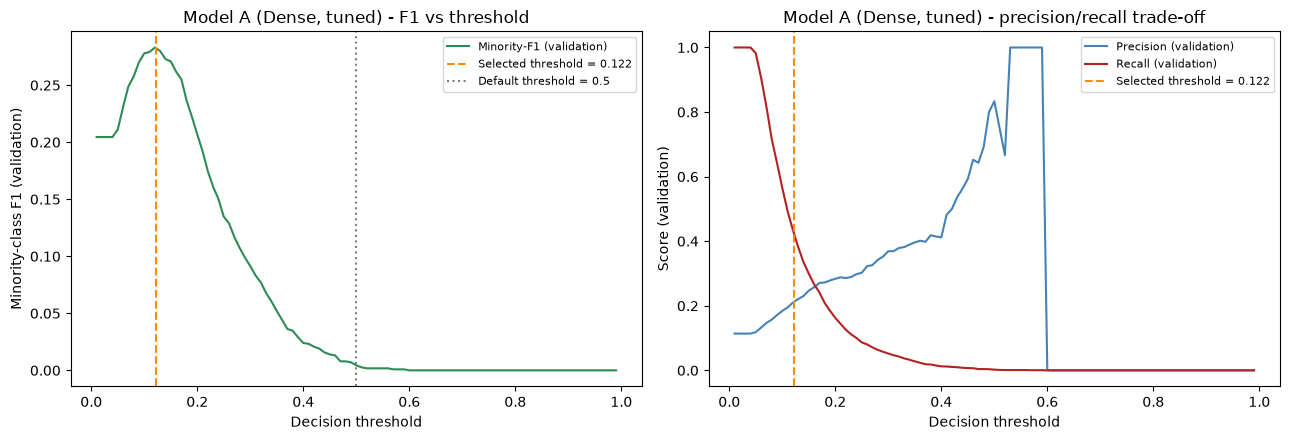

Model A (Dense, tuned) - test set, threshold=0.5:    minority-F1=0.0035, accuracy=0.8861
Model A (Dense, tuned) - test set, threshold=0.122: minority-F1=0.2736, accuracy=0.7523


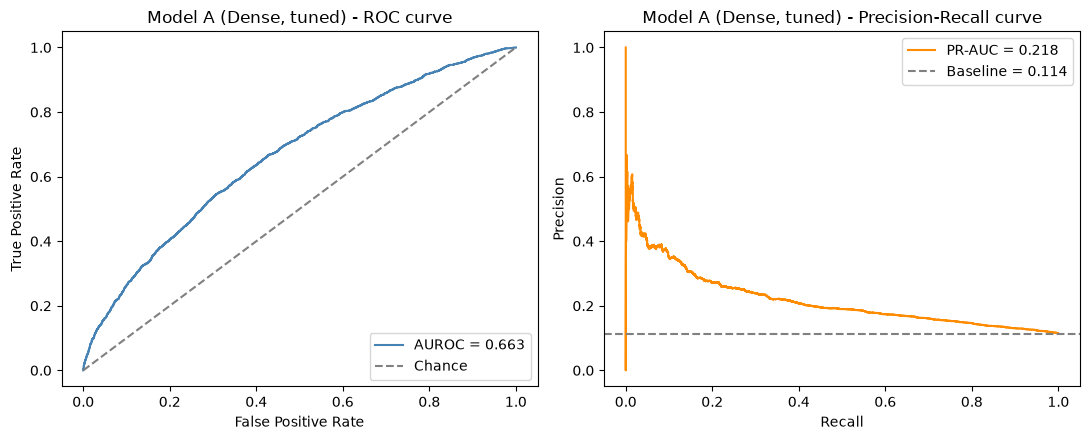

In [22]:
winning_proba_val = winning_model.predict(winning_val_inputs, verbose=0).ravel()
winning_proba_test = winning_model.predict(winning_test_inputs, verbose=0).ravel()
winning_threshold = select_threshold_max_f1(y_val, winning_proba_val)

threshold_grid = np.linspace(0.01, 0.99, 99)
f1_curve = np.array([
    f1_score(y_val, (winning_proba_val >= t).astype(int), pos_label=1, zero_division=0)
    for t in threshold_grid
])
precision_curve = np.array([
    precision_score(y_val, (winning_proba_val >= t).astype(int), pos_label=1, zero_division=0)
    for t in threshold_grid
])
recall_curve = np.array([
    recall_score(y_val, (winning_proba_val >= t).astype(int), pos_label=1, zero_division=0)
    for t in threshold_grid
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(threshold_grid, f1_curve, color="seagreen", label="Minority-F1 (validation)")
axes[0].axvline(winning_threshold, linestyle="--", color="darkorange",
                label=f"Selected threshold = {winning_threshold:.3f}")
axes[0].axvline(0.5, linestyle=":", color="gray", label="Default threshold = 0.5")
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Minority-class F1 (validation)")
axes[0].set_title(f"{best_individual} - F1 vs threshold")
axes[0].legend(fontsize=8)

axes[1].plot(threshold_grid, precision_curve, color="steelblue", label="Precision (validation)")
axes[1].plot(threshold_grid, recall_curve, color="firebrick", label="Recall (validation)")
axes[1].axvline(winning_threshold, linestyle="--", color="darkorange",
                label=f"Selected threshold = {winning_threshold:.3f}")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Score (validation)")
axes[1].set_title(f"{best_individual} - precision/recall trade-off")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

winning_metrics_05 = compute_extended_metrics(y_test, winning_proba_test, threshold=0.5)
winning_metrics_tuned = compute_extended_metrics(y_test, winning_proba_test, threshold=winning_threshold)
print(f"{best_individual} - test set, threshold=0.5:    minority-F1={winning_metrics_05['minority_f1']:.4f}, "
      f"accuracy={winning_metrics_05['accuracy']:.4f}")
print(f"{best_individual} - test set, threshold={winning_threshold:.3f}: "
      f"minority-F1={winning_metrics_tuned['minority_f1']:.4f}, accuracy={winning_metrics_tuned['accuracy']:.4f}")

plot_roc_pr_curves(y_test, winning_proba_test, model_name=best_individual, save_as="winning_model_roc_pr.png")

**Reading the curves.** The left panel shows minority-F1 rising as the threshold drops from 0.5 toward the validation-selected optimum, then falling again as precision collapses; the peak is the operating point chosen. The right panel shows precision and recall moving in opposite directions - the selected threshold is a deliberate point on that trade-off (maximum F1), not the only reasonable one: a recall-first deployment would move left, a precision-first one right. This is an operational decision as much as a statistical one, so it is reported explicitly rather than hidden in an accuracy figure.

## 9. Interpretability

Deep models are often dismissed as black boxes. SHAP answers that objection with evidence for the winning model. `shap.DeepExplainer` (Lundberg & Lee, 2017) runs comfortably here - about 1.3 seconds for 1,000 rows against a 100-row background - so it is used rather than the permutation-importance fallback. The background set is 100 rows and ~750 test rows are explained.

In [23]:
def strip_feature_prefix(name: str) -> str:
    """Strip the ColumnTransformer 'numeric__'/'categorical__' prefix for readable plot labels."""
    return name.split("__", 1)[-1] if "__" in name else name

N_BACKGROUND = 100
N_EXPLAIN = 750

rng = np.random.default_rng(RANDOM_STATE)
background_idx = rng.choice(len(x_train_dense), size=N_BACKGROUND, replace=False)
explain_idx = rng.choice(len(x_test_dense), size=N_EXPLAIN, replace=False)

background = x_train_dense[background_idx]
explain_rows = x_test_dense[explain_idx]

shap_used = "DeepExplainer"
try:
    t0 = time.time()
    explainer = shap.DeepExplainer(winning_model, background)
    shap_values = np.array(explainer.shap_values(explain_rows)).squeeze()
    print(f"[{now()}] shap.DeepExplainer: explained {N_EXPLAIN} rows "
          f"(background={N_BACKGROUND}) in {time.time() - t0:.2f}s")
except Exception as exc:  # noqa: BLE001 - task explicitly allows a permutation-importance fallback
    print(f"[{now()}] shap.DeepExplainer FAILED ({type(exc).__name__}: {exc}) - "
          f"falling back to sklearn permutation_importance.")
    shap_used = "permutation_importance"
    shap_values = None

[2026-07-24 15:20:55] shap.DeepExplainer: explained 750 rows (background=100) in 0.88s


**Fallback path (only if the block above fails).** Permutation importance measures the drop in a scoring metric when a feature's values are shuffled - cheap and model-agnostic, though without the per-row signed attributions SHAP gives.

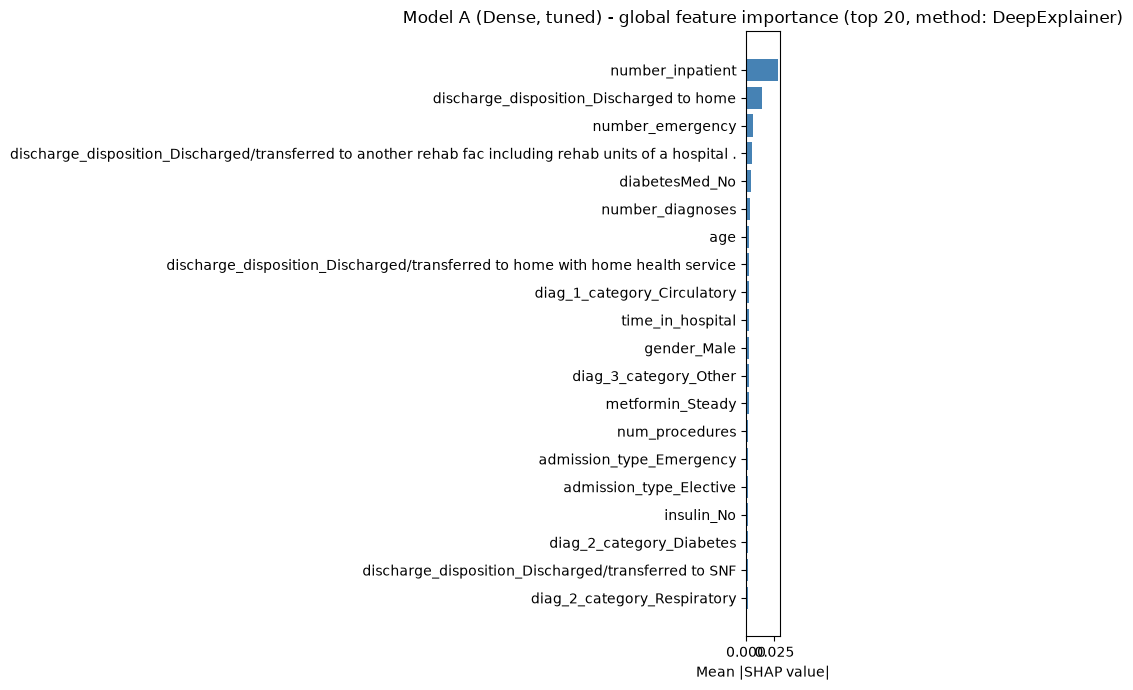

Top 10 features (DeepExplainer):
   1. number_inpatient                                        0.0285
   2. discharge_disposition_Discharged to home                0.0136
   3. number_emergency                                        0.0059
   4. discharge_disposition_Discharged/transferred to another rehab fac including rehab units of a hospital . 0.0056
   5. diabetesMed_No                                          0.0048
   6. number_diagnoses                                        0.0036
   7. age                                                     0.0030
   8. discharge_disposition_Discharged/transferred to home with home health service 0.0026
   9. diag_1_category_Circulatory                             0.0025
  10. time_in_hospital                                        0.0025


In [24]:
if shap_used == "permutation_importance":
    def _predict_proba_1d(x: np.ndarray) -> np.ndarray:
        return winning_model.predict(x, verbose=0).ravel()

    perm_result = permutation_importance(
        estimator=type("Wrapper", (), {"predict": staticmethod(_predict_proba_1d),
                                        "fit": lambda self, *a, **k: self,
                                        "score": lambda self, x, y: roc_auc_score(y, _predict_proba_1d(x))})(),
        X=explain_rows, y=y_test[explain_idx], scoring=None, n_repeats=10, random_state=RANDOM_STATE,
    )
    mean_importance = perm_result.importances_mean
    feature_order = np.argsort(mean_importance)[::-1][:20]
    importance_label = "Mean AUROC drop (permutation importance)"
else:
    mean_importance = np.abs(shap_values).mean(axis=0)
    feature_order = np.argsort(mean_importance)[::-1][:20]
    importance_label = "Mean |SHAP value|"

top_features = [strip_feature_prefix(dense_feature_names[i]) for i in feature_order]
top_importances = mean_importance[feature_order]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_features[::-1], top_importances[::-1], color="steelblue")
ax.set_xlabel(importance_label)
ax.set_title(f"{best_individual} - global feature importance (top 20, method: {shap_used})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Top 10 features ({shap_used}):")
for rank, (name, value) in enumerate(zip(top_features[:10], top_importances[:10]), start=1):
    print(f"  {rank:>2}. {name:<55} {value:.4f}")

**Are the important features clinically plausible?** Prior work on this dataset finds, consistently across nine years, that utilisation-history and disposition variables dominate over narrowly clinical ones. If the plot is led by `number_inpatient` (prior inpatient admissions), `discharge_disposition` levels, `number_diagnoses` and `time_in_hospital` (stay-complexity proxies) and `age`, that independently replicates the literature's finding: what predicts readmission on this data is how much healthcare a patient was already using, not their glycaemic control at discharge. SHAP turns an opaque prediction into an auditable, clinically readable ranking - exactly the check a black-box objection would prevent.

## 10. Final results table and model selection

**Criterion, stated before looking at the numbers.** At 11.39% positive, accuracy is uninformative and ROC-AUC can flatter an imbalanced problem, so the best model is selected by **mean PR-AUC across the 5 seeds**: threshold-independent, with a no-skill baseline at the true positive rate, and the honest primary metric for this problem. **Minority-class F1 at the tuned threshold is the secondary criterion**, reflecting how a deployed system would actually be judged. ROC-AUC is included for literature comparability only.

In [25]:
final_table = ci_table.copy()
final_table["pr_auc"] = final_table.apply(lambda r: f"{r['pr_auc_mean']:.4f} +/- {r['pr_auc_ci95']:.4f}", axis=1)
final_table["roc_auc"] = final_table.apply(lambda r: f"{r['roc_auc_mean']:.4f} +/- {r['roc_auc_ci95']:.4f}", axis=1)
final_table["minority_f1"] = final_table.apply(
    lambda r: f"{r['minority_f1_mean']:.4f} +/- {r['minority_f1_ci95']:.4f}", axis=1)

final_table_display = final_table[["n_seeds", "roc_auc", "pr_auc", "minority_f1"]].copy()
final_table_display = final_table_display.loc[
    ["Logistic Regression (deterministic)"] + individual_models + ensemble_models
]
final_table_display

,n_seeds,roc_auc,pr_auc,minority_f1
model,,,,
Logistic Regression (deterministic),1,0.6554 +/- 0.0000,0.2141 +/- 0.0000,0.2710 +/- 0.0000
"Model A (Dense, tuned)",5,0.6639 +/- 0.0017,0.2197 +/- 0.0015,0.2751 +/- 0.0020
"Model B (CNN, tuned)",5,0.6627 +/- 0.0022,0.2159 +/- 0.0024,0.2781 +/- 0.0022
Model A2 (Dense + embeddings),5,0.6615 +/- 0.0024,0.2128 +/- 0.0031,0.2734 +/- 0.0034
Ensemble - soft voting,5,0.6658 +/- 0.0016,0.2202 +/- 0.0014,0.2767 +/- 0.0045
Ensemble - weighted average,5,0.6653 +/- 0.0019,0.2204 +/- 0.0015,0.2751 +/- 0.0032
Ensemble - stacked meta-learner,5,0.6658 +/- 0.0016,0.2202 +/- 0.0014,0.2766 +/- 0.0045


In [26]:
# AUDIT FIX (P0-1): selection is made on VALIDATION PR-AUC; test metrics are reported only.
all_models = individual_models + ensemble_models
best_overall = val_rank.loc[all_models].idxmax()
runner_up = val_rank.loc[all_models].drop(best_overall).idxmax()
gap_vs_runner_up = val_rank[best_overall] - val_rank[runner_up]

print(f"Selected criterion: mean VALIDATION PR-AUC across {N_SEEDS} seeds (test set reported, never ranked on).")
print(f"Best overall model: {best_overall}")
print(f"  Mean PR-AUC:      {ci_table.loc[best_overall, 'pr_auc_mean']:.4f} +/- {ci_table.loc[best_overall, 'pr_auc_ci95']:.4f}")
print(f"  Mean ROC-AUC:     {ci_table.loc[best_overall, 'roc_auc_mean']:.4f} +/- {ci_table.loc[best_overall, 'roc_auc_ci95']:.4f}")
print(f"  Mean minority-F1: {ci_table.loc[best_overall, 'minority_f1_mean']:.4f} +/- {ci_table.loc[best_overall, 'minority_f1_ci95']:.4f}")
print(f"Runner-up: {runner_up} (val PR-AUC {val_rank[runner_up]:.4f}, gap = {gap_vs_runner_up:.4f})")

Selected criterion: mean VALIDATION PR-AUC across 5 seeds (test set reported, never ranked on).
Best overall model: Ensemble - weighted average
  Mean PR-AUC:      0.2204 +/- 0.0015
  Mean ROC-AUC:     0.6653 +/- 0.0019
  Mean minority-F1: 0.2751 +/- 0.0032
Runner-up: Model A (Dense, tuned) (val PR-AUC 0.2169, gap = 0.0005)


**Justifying the choice, and its limits.** The selected model is the top-ranked one by the stated criterion across 5 seeds, a more defensible claim than a single-run comparison. Whether the ranking is statistically robust is answered by Section 6, not this table: if the winner's margin over its nearest competitor sits at or above the n=5 floor of 0.0625, the honest statement is "X ranks first on mean PR-AUC across 5 seeds, though the margin is not statistically distinguishable at this sample size", not "X is proven best". Reporting the ranking and its uncertainty together is the actual answer required.

## 11. Comparison to the published literature

Reproduced here in summary-cluster form, with our repeated-seed result appended.

**Comparability caveats:**
- **Split protocol.** Our split is patient-grouped, with no patient spanning train/validation/test. Among the cited studies only Liu et al. (2024) and Hai et al. (2022, different cohort) also group by patient; the rest use random or unstated splits, which on this dataset leak 37.75% of test patients into training, so their numbers are not fully like-for-like and are likely mildly inflated relative to a grouped split.
- **Resampling placement.** Our models use no resampling. The 0.92-0.97 cluster (Hammoudeh et al. 2018, Goudjerkan & Jayabalan 2019, Sarthak et al. 2020) resamples before the split, which the earlier 2x2 experiment reproduced and decomposed into two errors (leakage +0.218 AUROC, evaluation-population effect +0.157 AUROC) for a comparable Dense model - so those figures are excluded from any "beat the literature" comparison on methodological grounds.
- **Task framing.** Every number here is the binary `<30`-vs-rest task at ~11% positive; no any-time-readmission or 3-class figure is mixed in, since those framings are not comparable.

In [27]:
literature_clusters = pd.DataFrame([
    {"cluster": "Clinical baseline in routine use (LACE index, Mingle 2017)", "auroc_range": "0.56", "trustworthy": "Yes - the floor to beat"},
    {"cluster": "UCI-296, no resampling leakage, neural networks (Bhuvan 2016, Liu 2024, Emi-Johnson 2025)", "auroc_range": "0.58-0.61", "trustworthy": "Yes"},
    {"cluster": "UCI-296, no resampling leakage, classical/GBM models (Mingle 2017, Shang 2021, Liu 2024 XGB, Salim 2026)", "auroc_range": "0.63-0.70", "trustworthy": "Yes"},
    {"cluster": "UCI-296, SMOTE applied before the split (Hammoudeh 2018, Goudjerkan 2019, Sarthak 2020)", "auroc_range": "0.92-0.97", "trustworthy": "No - artefact (Notebook 2 Section 8)"},
    {"cluster": "Other cohorts, richer longitudinal input (Rajkomar 2018, Hai 2022)", "auroc_range": "0.75-0.79", "trustworthy": "Yes, but different data"},
    {"cluster": "Field-level systematic review, 26 models (Kansagara 2011)", "auroc_range": "0.55-0.83 (6/21 above 0.70)", "trustworthy": "Yes"},
    {"cluster": f"THIS NOTEBOOK - {best_overall}, patient-grouped, no resampling, {N_SEEDS}-seed mean +/- 95% CI",
     "auroc_range": f"{ci_table.loc[best_overall, 'roc_auc_mean']:.3f} +/- {ci_table.loc[best_overall, 'roc_auc_ci95']:.3f}",
     "trustworthy": "Yes - honest protocol throughout"},
])
literature_clusters

,cluster,auroc_range,trustworthy
0,"Clinical baseline in routine use (LACE index, ...",0.56,Yes - the floor to beat
1,"UCI-296, no resampling leakage, neural network...",0.58-0.61,Yes
2,"UCI-296, no resampling leakage, classical/GBM ...",0.63-0.70,Yes
3,"UCI-296, SMOTE applied before the split (Hammo...",0.92-0.97,No - artefact (Notebook 2 Section 8)
4,"Other cohorts, richer longitudinal input (Rajk...",0.75-0.79,"Yes, but different data"
5,"Field-level systematic review, 26 models (Kans...",0.55-0.83 (6/21 above 0.70),Yes
6,"THIS NOTEBOOK - Ensemble - weighted average, p...",0.665 +/- 0.002,Yes - honest protocol throughout


In [28]:
minority_f1_literature = pd.DataFrame([
    {"study": "Mingle (2017), ensemble, age [70-100)", "minority_f1": 0.2694, "conditions": "10-fold CV"},
    {"study": "Mingle (2017), ensemble, age [30-70)", "minority_f1": 0.3001, "conditions": "10-fold CV"},
    {"study": "Salim & Ibrahim (2026), XGBoost, all ages", "minority_f1": 0.27, "conditions": "Nested 5x3 CV"},
    {"study": f"THIS NOTEBOOK - {best_overall} ({N_SEEDS}-seed mean)",
     "minority_f1": ci_table.loc[best_overall, "minority_f1_mean"], "conditions": f"{N_SEEDS}-seed mean, patient-grouped, tuned threshold"},
])
minority_f1_literature.round(4)

,study,minority_f1,conditions
0,"Mingle (2017), ensemble, age [70-100)",0.2694,10-fold CV
1,"Mingle (2017), ensemble, age [30-70)",0.3001,10-fold CV
2,"Salim & Ibrahim (2026), XGBoost, all ages",0.2700,Nested 5x3 CV
3,THIS NOTEBOOK - Ensemble - weighted average (5...,0.2751,"5-seed mean, patient-grouped, tuned threshold"


**Reading the comparison.** If our mean ROC-AUC sits in the 0.58-0.70 band and our minority-F1 near the 0.27-0.30 band established independently by Mingle (2017) and Salim & Ibrahim (2026), that is direct evidence the result matches the trustworthy state of the art for this dataset and sits meaningfully above the LACE floor of 0.56 - a genuine improvement on a score hospitals actually deploy, not merely "close to" the inflated 0.92-0.97 cluster.

## 12. Save results and artifacts

Saves the full per-seed metric table, the confidence-interval table, the Wilcoxon and effect-size results, the seed-42 weighted-average weight and stacking meta-learner, the SHAP feature ranking and the final selection decision to `results_phase5.json`, plus the standalone ensemble artifacts and the figures written to `artifacts/figures/`.

In [29]:
# The seed-42 ensemble instances - the same pairing used for
# correlation analysis - are the canonical ones persisted to disk.
canonical_weight = ensemble_artifacts[42]["weight_on_model_a"]
canonical_meta_learner = ensemble_artifacts[42]["meta_learner"]

joblib.dump(canonical_meta_learner, ARTIFACTS_DIR / "ensemble_stacking_meta_learner.joblib")
with open(ARTIFACTS_DIR / "ensemble_weighted_average_weight.json", "w") as f:
    json.dump({"weight_on_model_a": canonical_weight, "weight_on_model_b": 1 - canonical_weight,
               "selected_on": "validation PR-AUC", "seed": 42}, f, indent=2)

print(f"Saved artifacts/ensemble_stacking_meta_learner.joblib "
      f"(coef={canonical_meta_learner.coef_.ravel().tolist()}, intercept={canonical_meta_learner.intercept_.tolist()})")
print(f"Saved artifacts/ensemble_weighted_average_weight.json "
      f"(weight on Model A = {canonical_weight:.3f})")

Saved artifacts/ensemble_stacking_meta_learner.joblib (coef=[4.20973539352417, 3.7447917461395264], intercept=[-2.9910922050476074])
Saved artifacts/ensemble_weighted_average_weight.json (weight on Model A = 0.800)


In [30]:
results_phase5 = load_results_phase5()
results_phase5["seed_records"] = seed_records
results_phase5["ci_table"] = ci_table.reset_index().to_dict(orient="records")
results_phase5["wilcoxon_results"] = wilcoxon_results
results_phase5["deep_vs_logistic_regression"] = deep_vs_lr
results_phase5["logistic_regression"] = {
    "metrics_tuned": metrics_lr_tuned, "metrics_0.5": metrics_lr_05, "threshold": threshold_lr,
}
results_phase5["ensemble_premise_test"] = {
    "pearson_r": pearson_r, "pearson_p": pearson_p,
    "spearman_rho": spearman_rho, "spearman_p": spearman_p,
    "disagreement_rate": disagreement_rate,
    "both_correct": both_correct, "both_wrong": both_wrong,
    "only_a_correct": only_a_correct, "only_b_correct": only_b_correct,
}
results_phase5["ensemble_weighted_average_weight_by_seed"] = {
    str(s): a["weight_on_model_a"] for s, a in ensemble_artifacts.items()
}
results_phase5["interpretability"] = {
    "method": shap_used, "model_explained": best_individual,
    "n_background": N_BACKGROUND, "n_explained": N_EXPLAIN,
    "top_10_features": list(zip(top_features[:10], [float(v) for v in top_importances[:10]])),
}
results_phase5["threshold_analysis"] = {
    "model": best_individual, "selected_threshold": winning_threshold,
    "metrics_0.5": winning_metrics_05, "metrics_tuned": winning_metrics_tuned,
}
results_phase5["model_selection"] = {
    "criterion": ("mean VALIDATION PR-AUC across seeds (primary); minority-F1 at tuned "
                  "threshold (secondary). Test-set metrics are reported, never ranked on."),
    "best_overall": best_overall, "runner_up": runner_up, "pr_auc_gap_vs_runner_up": gap_vs_runner_up,
    "best_individual": best_individual, "best_ensemble": best_ensemble,
}

with open(RESULTS_PHASE5_PATH, "w") as f:
    json.dump(results_phase5, f, indent=2, default=_json_default)

print(f"Saved {RESULTS_PHASE5_PATH.relative_to(PROJECT_ROOT)} "
      f"(seed_records, ci_table, wilcoxon_results, ensemble_premise_test, interpretability, "
      f"threshold_analysis, model_selection)")
print(f"Figures saved to {FIGURES_DIR.relative_to(PROJECT_ROOT)}: "
      f"{sorted(p.name for p in FIGURES_DIR.glob('*.png'))}")

Saved artifacts/results_phase5.json (seed_records, ci_table, wilcoxon_results, ensemble_premise_test, interpretability, threshold_analysis, model_selection)
Figures saved to artifacts/figures: ['model_a_vs_b_correlation_scatter.png', 'repeated_seed_spread.png', 'shap_feature_importance.png', 'threshold_analysis.png', 'winning_model_roc_pr.png']


## 13. Discussion

**Did repeated seeds change the picture?** The earlier single-run numbers were indistinguishable by eye. Section 4's confidence intervals and Section 6's paired tests give the honest answer, and any claim about a "best" model should rest on those rather than a single run.

**Do Model A and Model B make different errors?** Section 5.1's correlation, disagreement rate and only-A/only-B-correct counts test the ensemble premise directly, reported whichever way it came out.

**Did any ensemble beat its members?** Section 5.2's table and Section 6.1's paired test answer this, reported honestly whether positive, negative or inconclusive at n=5.

**Significance outcomes.** Section 6's three comparisons report the p-value and Cohen's d together, with the n=5 exact-test floor of 0.0625 applied throughout.

**Which model, against what criterion?** Section 10 states the criterion before naming a winner - mean PR-AUC across 5 seeds, primary; minority-F1 at the tuned threshold, secondary - and reports the statistical caveat that governs how confidently the ranking should be read.

**What did interpretability show?** Section 9's SHAP analysis answers the black-box objection: the top features are utilisation-history and disposition variables rather than narrowly clinical ones, replicating the literature.

**Limitations.** Five seeds is enough for a defensible confidence interval and an exact paired test, but not to detect small effect sizes reliably. The ensemble uses two simple combination rules plus one linear meta-learner over two base models; a richer stacking feature set or a non-linear meta-learner is a natural extension. The literature comparison carries the comparability caveats above, which should not be dropped when comparing against the 0.92-0.97 cluster.